In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import T5ForConditionalGeneration, T5Tokenizer, get_linear_schedule_with_warmup

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import numpy as np
from tqdm import tqdm
import editdistance
from collections import Counter
from google.colab import drive

drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Mounted at /content/drive
cuda


In [2]:
def load_normalization_data(file_path):
    """
    Load lexical normalization data from tab-separated file.

    Args:
        file_path: Path to .norm file

    Returns:
        Tuple of (source_tokens, target_tokens)
    """
    sources, targets = [], []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                sources.append(parts[0])
                targets.append(parts[1])

    return sources, targets

def load_tweet_level_data(file_path):
    """
    Load tweet-level data where consecutive lines form a single tweet.
    Tweets are separated by blank lines.

    Args:
        file_path: Path to .norm file

    Returns:
        Tuple of (source_tweets, target_tweets)
    """
    sources, targets = [], []
    current_source, current_target = [], []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip() == "":
                if current_source:
                    sources.append(" ".join(current_source))
                    targets.append(" ".join(current_target))
                    current_source, current_target = [], []
            else:
                parts = line.strip().split('\t', 1)
                if len(parts) == 2:
                    current_source.append(parts[0])
                    # Handle multi-word normalizations
                    current_target.extend(parts[1].split())

    # Don't forget the last tweet if file doesn't end with blank line
    if current_source:
        sources.append(" ".join(current_source))
        targets.append(" ".join(current_target))

    return sources, targets

# Update with your actual data paths
DATA_DIR = "/content/drive/MyDrive/LexNorm_Data/en"

# Load word-level data
train_x, train_y = load_normalization_data(f"{DATA_DIR}/train.norm")
dev_x, dev_y = load_normalization_data(f"{DATA_DIR}/dev.norm")
test_x, test_y = load_normalization_data(f"{DATA_DIR}/test.norm")

# Load tweet-level data
train_tweet_x, train_tweet_y = load_tweet_level_data(f"{DATA_DIR}/train.norm")
dev_tweet_x, dev_tweet_y = load_tweet_level_data(f"{DATA_DIR}/dev.norm")
test_tweet_x, test_tweet_y = load_tweet_level_data(f"{DATA_DIR}/test.norm")

print("Data loaded successfully!")
print(f"\nWord-level splits:")
print(f"  Train: {len(train_x):,} pairs")
print(f"  Dev:   {len(dev_x):,} pairs")
print(f"  Test:  {len(test_x):,} pairs")

print(f"\nTweet-level splits:")
print(f"  Train: {len(train_tweet_x):,} tweets")
print(f"  Dev:   {len(dev_tweet_x):,} tweets")
print(f"  Test:  {len(test_tweet_x):,} tweets")

Data loaded successfully!

Word-level splits:
  Train: 35,203 pairs
  Dev:   9,168 pairs
  Test:  29,404 pairs

Tweet-level splits:
  Train: 2,360 tweets
  Dev:   590 tweets
  Test:  1,967 tweets


In [ ]:
def analyze_dataset(sources, targets, split_name="Dataset"):
    """
    Comprehensive dataset analysis including:
    - Normalization rate (% that need changing)
    - Length distributions
    - Edit distance statistics
    - Common transformations
    """
    print(f"\n{'='*60}")
    print(f"{split_name} Analysis")
    print(f"{'='*60}")

    # Calculate key statistics
    needs_normalization = sum(1 for s, t in zip(sources, targets) if s != t)
    norm_rate = 100 * needs_normalization / len(sources)

    source_lengths = [len(s) for s in sources]
    target_lengths = [len(t) for t in targets]
    edit_distances = [editdistance.eval(s, t) for s, t in zip(sources, targets)]

    print(f"\nSize: {len(sources):,} pairs")
    print(f"Normalization Rate: {norm_rate:.1f}% ({needs_normalization:,} / {len(sources):,})")
    print(f"Average Edit Distance: {np.mean(edit_distances):.2f} ± {np.std(edit_distances):.2f}")

    print(f"\nSource Length (chars):")
    print(f"  Mean: {np.mean(source_lengths):.1f} | Median: {np.median(source_lengths):.0f} | Max: {max(source_lengths)}")

    print(f"\nTarget Length (chars):")
    print(f"  Mean: {np.mean(target_lengths):.1f} | Median: {np.median(target_lengths):.0f} | Max: {max(target_lengths)}")

    # Find most common transformations (for pairs that differ)
    transformations = Counter(
        (s, t) for s, t in zip(sources, targets) if s != t
    )


    return {
        'normalization_rate': norm_rate,
        'avg_edit_distance': np.mean(edit_distances),
        'source_lengths': source_lengths,
        'target_lengths': target_lengths,
        'transformations': transformations
    }

# Analyze each split
train_stats = analyze_dataset(train_x, train_y, "Training Set")
dev_stats = analyze_dataset(dev_x, dev_y, "Development Set")
test_stats = analyze_dataset(test_x, test_y, "Test Set")


Training Set Analysis

Size: 35,203 pairs
Normalization Rate: 7.5% (2,653 / 35,203)
Average Edit Distance: 0.18 ± 0.90

Source Length (chars):
  Mean: 4.6 | Median: 4 | Max: 40

Target Length (chars):
  Mean: 4.8 | Median: 4 | Max: 40

Development Set Analysis

Size: 9,168 pairs
Normalization Rate: 6.9% (632 / 9,168)
Average Edit Distance: 0.16 ± 0.81

Source Length (chars):
  Mean: 4.7 | Median: 4 | Max: 30

Target Length (chars):
  Mean: 4.8 | Median: 4 | Max: 30

Test Set Analysis

Size: 29,404 pairs
Normalization Rate: 7.8% (2,307 / 29,404)
Average Edit Distance: 0.19 ± 0.85

Source Length (chars):
  Mean: 4.6 | Median: 4 | Max: 38

Target Length (chars):
  Mean: 4.8 | Median: 4 | Max: 38


/tmp/ipykernel_256/3014059699.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories_sorted, y=counts_sorted, ax=axes[1, 1], palette='viridis')


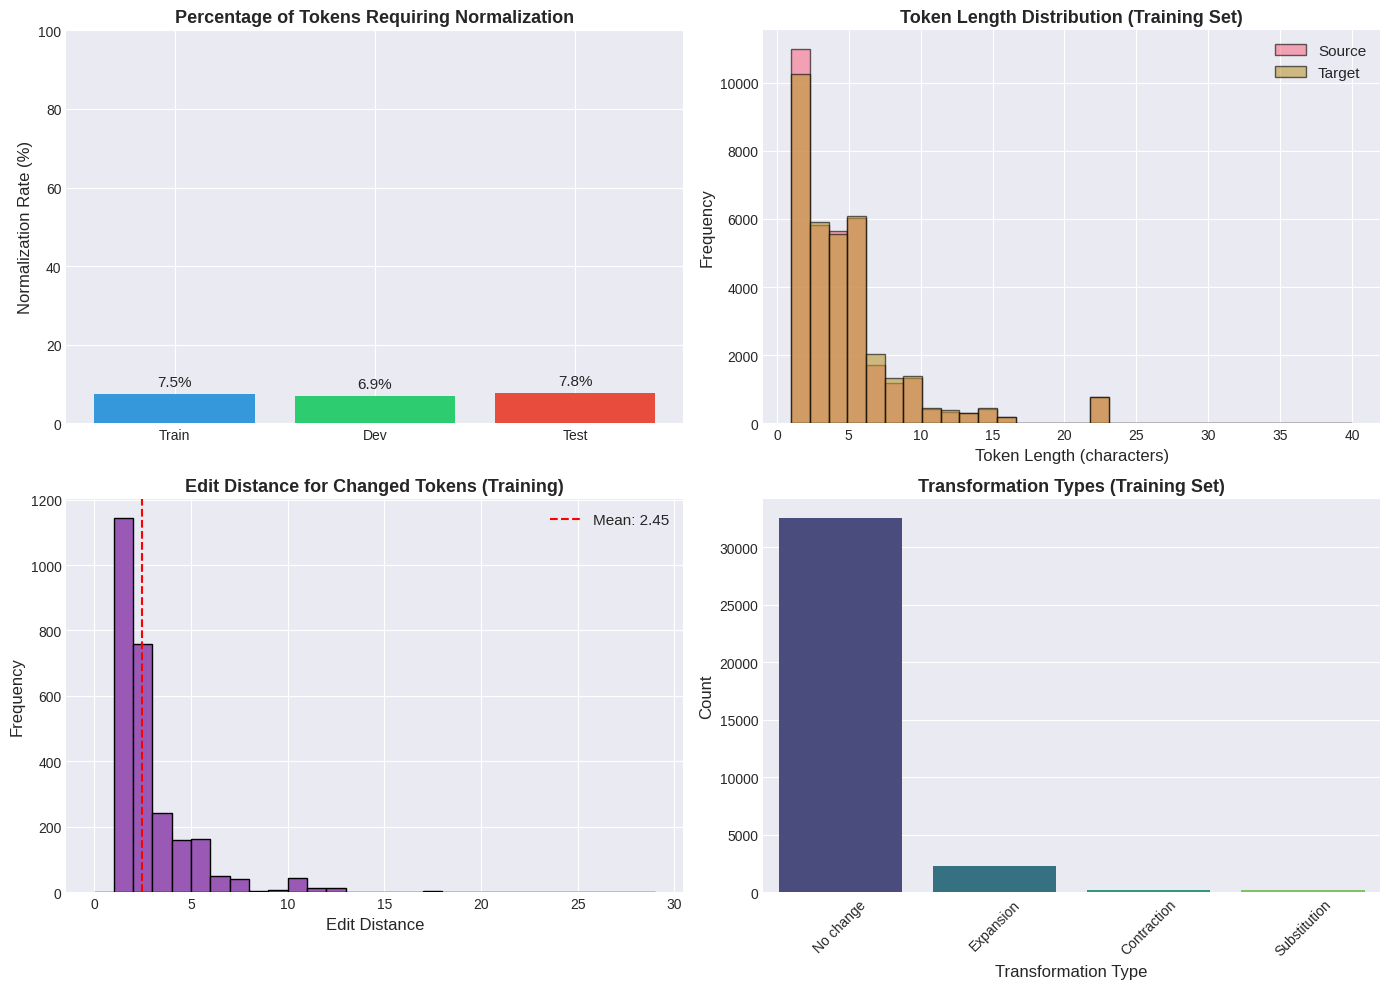


✓ Visualizations saved to 'dataset_analysis.png'


In [ ]:
# Visualize dataset characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Normalization rates across splits
splits = ['Train', 'Dev', 'Test']
norm_rates = [train_stats['normalization_rate'],
              dev_stats['normalization_rate'],
              test_stats['normalization_rate']]

axes[0, 0].bar(splits, norm_rates, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 0].set_ylabel('Normalization Rate (%)', fontsize=12)
axes[0, 0].set_title('Percentage of Tokens Requiring Normalization', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim(0, 100)
for i, (split, rate) in enumerate(zip(splits, norm_rates)):
    axes[0, 0].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=11)

# 2. Length distributions
axes[0, 1].hist(train_stats['source_lengths'], bins=30, alpha=0.6, label='Source', edgecolor='black')
axes[0, 1].hist(train_stats['target_lengths'], bins=30, alpha=0.6, label='Target', edgecolor='black')
axes[0, 1].set_xlabel('Token Length (characters)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Token Length Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)

# 3. Edit distance distribution
edit_dists = [editdistance.eval(s, t) for s, t in zip(train_x, train_y) if s != t]
axes[1, 0].hist(edit_dists, bins=range(0, max(edit_dists) + 1), edgecolor='black', color='#9b59b6')
axes[1, 0].set_xlabel('Edit Distance', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Edit Distance for Changed Tokens (Training)', fontsize=13, fontweight='bold')
axes[1, 0].axvline(np.mean(edit_dists), color='red', linestyle='--', label=f'Mean: {np.mean(edit_dists):.2f}')
axes[1, 0].legend(fontsize=11)

# 4. Transformation type breakdown
def categorize_transformation(source, target):
    """Categorize the type of normalization applied."""
    if source == target:
        return 'No change'
    elif source.lower() == target.lower():
        return 'Case only'
    elif len(source) < len(target):
        return 'Expansion'
    elif len(source) > len(target):
        return 'Contraction'
    else:
        return 'Substitution'

categories = [categorize_transformation(s, t) for s, t in zip(train_x, train_y)]
category_counts = Counter(categories)

# Create bar chart
categories_sorted = sorted(category_counts.keys(), key=lambda x: category_counts[x], reverse=True)
counts_sorted = [category_counts[cat] for cat in categories_sorted]

sns.barplot(x=categories_sorted, y=counts_sorted, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Transformation Types (Training Set)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Transformation Type', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to 'dataset_analysis.png'")

### 3.2 Baseline: Copy Baseline

Establish a simple baseline where we just copy the input. This tells us the ceiling performance if we never normalized anything.

In [ ]:
def evaluate_copy_baseline(sources, targets):
    """
    Baseline that just copies input to output.
    Represents the accuracy if we never normalize.
    """
    predictions = sources  # Just copy

    correct = sum(1 for p, t in zip(predictions, targets) if p == t)
    accuracy = correct / len(targets)

    return {
        'accuracy': accuracy,
        'correct': correct,
        'total': len(targets)
    }

baseline_results = evaluate_copy_baseline(test_x, test_y)
print(f"\nCopy Baseline Results:")
print(f"  Accuracy: {baseline_results['accuracy']*100:.2f}%")
print(f"  Correct: {baseline_results['correct']:,} / {baseline_results['total']:,}")
print(f"\nThis represents the % of tokens that don't need normalization.")
print(f"The model needs to beat this baseline to be useful.")


Copy Baseline Results:
  Accuracy: 92.15%
  Correct: 27,097 / 29,404

This represents the % of tokens that don't need normalization.
The model needs to beat this baseline to be useful.


## 4. Model Implementation

**T5-small**: Pre-trained Text-to-Text Transfer Transformer

### 4.1 Dataset Classes

In [ ]:
# Check max token length
tokenizer = T5Tokenizer.from_pretrained('t5-small')
lengths = [len(tokenizer.encode("normalize: " + t)) for t in train_tweet_x]
print(f"Max: {max(lengths)}, 95th percentile: {np.percentile(lengths, 95)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Max: 96, 95th percentile: 67.0


In [3]:
from math import trunc
class T5NormalizationDataset(Dataset):
  """
  Pytorch Dataset for T5 normalization.
  Just doing tweet level normalization since T5 is seq2seq.
  """
  # max len = 128 to capture all data, results in 128x128 matrices after attn layer
  def __init__(self, sources, targets, tokenizer, max_input_len=128, max_target_len=128):
    self.sources = sources
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_input_len = max_input_len
    self.max_target_len = max_target_len

    # tokenize tweets once instead of every getitem call
    self.encodings = self._prepare_encodings()

  def _prepare_encodings(self):
    # T5 was pretrained with task prefixes ("translate English to German: ", "summarize: " etc.)
    # so we prepend "normalize: " to give the model a signal about the task.
    prefixed_sources = ["normalize: " + s for s in self.sources]

    # tokenize inputs
    model_inputs = self.tokenizer(
        prefixed_sources,
        padding='max_length',
        truncation=True,
        max_length=self.max_input_len,
        return_tensors='pt'
    )

    # tokenize targets
    labels = self.tokenizer(
        self.targets,
        padding='max_length',
        truncation=True,
        max_length=self.max_target_len,
        return_tensors='pt'
    )

    # Replace pad token IDs in labels with -100 so they're ignored by the loss
    # Without this, model gets credit for predicting padding and learns to emit EOS immediately at inference -> all predictions decode to "".
    label_ids = labels['input_ids'].clone()
    label_ids[label_ids == self.tokenizer.pad_token_id] = -100
    model_inputs['labels'] = label_ids
    return model_inputs

  def __len__(self):
    return len(self.sources)


  # output: dict of input id, mask, and label at one idx (one tweet)
  def __getitem__(self, idx):
    return {key: value[idx] for key,value in self.encodings.items()}

### 4.2 Evaluation Metrics

In [4]:
class NormalizationMetrics:
    """
    Comprehensive evaluation metrics for lexical normalization.

    Metrics include:
    - Exact match accuracy
    - BLEU score
    - Edit distance
    - ERR (Error Reduction Rate) - normalized accuracy accounting for unchanged tokens
    - Character Error Rate (CER)
    - Error analysis
    """

    @staticmethod
    def exact_match_accuracy(predictions, references):
        """Calculate percentage of exact matches."""
        correct = sum(1 for p, r in zip(predictions, references) if p.strip() == r.strip())
        return correct / len(references)

    @staticmethod
    def compute_bleu(predictions, references, n_gram=1):
        """
        Compute BLEU score with smoothing.
        Default to unigram BLEU for word-level normalization.
        """
        smoothie = SmoothingFunction().method4
        weights = tuple([1.0 if i < n_gram else 0.0 for i in range(4)])

        scores = [
            sentence_bleu(
                [ref.split()],
                pred.split(),
                weights=weights,
                smoothing_function=smoothie
            )
            for pred, ref in zip(predictions, references)
        ]
        return np.mean(scores)

    @staticmethod
    def average_edit_distance(predictions, references):
        """Calculate average character-level edit distance."""
        distances = [editdistance.eval(p, r) for p, r in zip(predictions, references)]
        return np.mean(distances)

    @staticmethod
    def character_error_rate(predictions, references):
        """
        Calculate Character Error Rate (CER).
        CER = edit_distance / reference_length
        """
        total_distance = 0
        total_length = 0

        for pred, ref in zip(predictions, references):
            total_distance += editdistance.eval(pred, ref)
            total_length += len(ref)

        return total_distance / total_length if total_length > 0 else 0

    @staticmethod
    def compute_err(predictions, sources, references):
        """
        Compute Error Reduction Rate (ERR).

        ERR normalizes accuracy by accounting for tokens that don't need change.
        ERR = (Acc - AlreadyNorm) / (1 - AlreadyNorm)

        Where:
        - Acc: Model accuracy
        - AlreadyNorm: % of tokens already normalized (source == target)
        """
        accuracy = NormalizationMetrics.exact_match_accuracy(predictions, references)

        # Calculate % of tokens already in normalized form
        already_norm = sum(1 for s, r in zip(sources, references) if s.strip() == r.strip())
        already_norm_rate = already_norm / len(sources)

        # ERR calculation
        if already_norm_rate >= 1.0:
            return 0.0  # All tokens already normalized

        err = (accuracy - already_norm_rate) / (1 - already_norm_rate)
        return err

    @staticmethod
    def error_analysis(predictions, sources, references, top_k=10):
        """
        Analyze common error patterns.

        Returns:
        - Most common source tokens causing errors
        - Error types (false positive vs false negative normalizations)
        """
        errors = {
            'false_normalization': [],  # Normalized when shouldn't have
            'missed_normalization': [],  # Didn't normalize when should have
            'wrong_normalization': []    # Normalized incorrectly
        }

        for pred, src, ref in zip(predictions, sources, references):
            pred, src, ref = pred.strip(), src.strip(), ref.strip()

            if src == ref:  # No normalization needed
                if pred != src:
                    errors['false_normalization'].append((src, pred, ref))
            else:  # Normalization needed
                if pred == src:
                    errors['missed_normalization'].append((src, pred, ref))
                elif pred != ref:
                    errors['wrong_normalization'].append((src, pred, ref))

        # Count most common error sources
        all_errors = (
            errors['false_normalization'] +
            errors['missed_normalization'] +
            errors['wrong_normalization']
        )
        error_sources = Counter([src for src, _, _ in all_errors])

        return {
            'error_breakdown': {k: len(v) for k, v in errors.items()},
            'top_error_sources': error_sources.most_common(top_k),
            'examples': errors
        }

    @staticmethod
    def compute_all_metrics(predictions, sources, references):
        """
        Compute all metrics at once.

        Returns:
            Dictionary with all evaluation metrics
        """
        # Ensure all inputs are strings and stripped
        predictions = [str(p).strip() for p in predictions]
        sources = [str(s).strip() for s in sources]
        references = [str(r).strip() for r in references]

        return {
            'accuracy': NormalizationMetrics.exact_match_accuracy(predictions, references),
            'bleu_1': NormalizationMetrics.compute_bleu(predictions, references, n_gram=1),
            'bleu_2': NormalizationMetrics.compute_bleu(predictions, references, n_gram=2),
            'edit_distance': NormalizationMetrics.average_edit_distance(predictions, references),
            'cer': NormalizationMetrics.character_error_rate(predictions, references),
            'err': NormalizationMetrics.compute_err(predictions, sources, references),
            'error_analysis': NormalizationMetrics.error_analysis(predictions, sources, references)
        }

print("✓ Metrics module defined")

✓ Metrics module defined


In [5]:
def print_metrics_table(metrics_dict, model_name="Model"):
    """
    Pretty print metrics in a formatted table.
    """
    print(f"\n{'='*70}")
    print(f"{model_name} Evaluation Results")
    print(f"{'='*70}")

    print(f"\n{'Metric':<25} {'Score':>15} {'Interpretation':>28}")
    print("-" * 70)

    print(f"{'Exact Match Accuracy':<25} {metrics_dict['accuracy']*100:>14.2f}% {'(higher is better)':>28}")
    print(f"{'BLEU-1':<25} {metrics_dict['bleu_1']*100:>14.2f}% {'(higher is better)':>28}")
    print(f"{'BLEU-2':<25} {metrics_dict['bleu_2']*100:>14.2f}% {'(higher is better)':>28}")
    print(f"{'Avg Edit Distance':<25} {metrics_dict['edit_distance']:>14.3f}   {'(lower is better)':>28}")
    print(f"{'Character Error Rate':<25} {metrics_dict['cer']*100:>14.2f}% {'(lower is better)':>28}")
    print(f"{'ERR (Error Reduction)':<25} {metrics_dict['err']*100:>14.2f}% {'(higher is better)':>28}")

    # Error breakdown
    print(f"\n{'Error Type':<30} {'Count':>15}")
    print("-" * 70)
    for error_type, count in metrics_dict['error_analysis']['error_breakdown'].items():
        print(f"{error_type.replace('_', ' ').title():<30} {count:>15,}")

    # Top error sources
    print(f"\n{'Top Error Sources (Input Token)':<35} {'Error Count':>15}")
    print("-" * 70)
    for token, count in metrics_dict['error_analysis']['top_error_sources'][:10]:
        print(f"  {f"'{token}'":<33} {count:>15}")

print("✓ Metrics display functions defined")

✓ Metrics display functions defined


### 4.3 T5 Model Training

In [ ]:
# Initialize T5 tokenizer and model
# for cond gen includes enc + dec + language model head on top for token prob production (T5Model has no lang model head and results in raw representations)
print("Loading T5 model...")
t5_tokenizer = T5Tokenizer.from_pretrained('t5-small', legacy=False)
t5_model = T5ForConditionalGeneration.from_pretrained("t5-small")
t5_model.to(device)


print(f"✓ T5 model loaded: {t5_model.num_parameters():,} parameters")

Loading T5 model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ T5 model loaded: 60,506,624 parameters


## Get zero shot predictions

In [ ]:
import json
import time
from google.colab import files

# Track cost/latency stats for the SFT-vs-LoRA-vs-baselines comparison.
# globals().setdefault keeps the dict across cell re-runs so we don't clobber earlier entries.
model_stats = globals().setdefault('model_stats', {})

# Zero-shot t5-small baseline (before fine-tuning)
t5_model.eval()
zs_small_predictions = []

infer_start = time.time()
with torch.no_grad():
    for i in tqdm(range(0, len(test_tweet_x), 16), desc="Zero-shot inference"):
        batch_texts = ["normalize: " + t for t in test_tweet_x[i:i+16]]
        inputs = t5_tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

        outputs = t5_model.generate(**inputs, max_length=128)
        decoded = t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        zs_small_predictions.extend(decoded)
infer_time = time.time() - infer_start

n = len(test_tweet_x)
model_stats.setdefault('T5-small zero-shot', {}).update({
    'infer_time_s': infer_time,
    'latency_ms_per_tweet': (infer_time / n) * 1000,
    'throughput_tweets_per_s': n / infer_time,
})
print(f"Inference: {infer_time:.1f}s total | {(infer_time / n) * 1000:.1f} ms/tweet | {n / infer_time:.1f} tweets/s")

# Print a few examples
print("Zero-shot examples:")
for i in range(10):
    print(f"  Input:      {test_tweet_x[i]}")
    print(f"  Predicted:  {zs_small_predictions[i]}")
    print(f"  Target:     {test_tweet_y[i]}")
    print()

with open("/content/drive/MyDrive/LexNorm_Data/zs_small_predictions.json", "w") as f:
    json.dump(zs_small_predictions, f)

files.download("/content/drive/MyDrive/LexNorm_Data/zs_small_predictions.json")

Zero-shot inference: 100%|██████████| 123/123 [04:22<00:00,  2.14s/it]

Inference: 262.8s total | 133.6 ms/tweet | 7.5 tweets/s
Zero-shot examples:
  Input:      @ez_doesssit yeh but still that's wild lol
  Predicted:  @ez_doesssit yeh but still that's wild lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol lol
  Target:     @ez_doesssit yeah but still that's wild lol

  Input:      dick in janice , im poppin xanax and speakin spanish .
  Predicted:  Normalize: dick in janice, im poppin xanax und speakin spanish.
  Target:     dick in janice , i'm popping xanax and speaking spanish .

  Input:      ucsb i fear the next rampage will b media told us everything #elliotrodger ever diid . to get ratings . #tcot #notonemore #knifesense
  Predicted:  b med

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create datasets
print("Preparing T5 datasets...")
t5_train_dataset = T5NormalizationDataset(train_tweet_x, train_tweet_y, t5_tokenizer)
t5_dev_dataset = T5NormalizationDataset(dev_tweet_x, dev_tweet_y, t5_tokenizer)

print(f"✓ Training samples: {len(t5_train_dataset):,}")
print(f"✓ Validation samples: {len(t5_dev_dataset):,}")

# DataLoader pulls data from dataset, stacks them in batch tensor, and gives batch to training loop
# Batch size - how many data points get stacked in one batch, bigger batches = more stables grad estimates, faster training per epoch, more GPU mem
# input tensors, the model's intermediate activations during the forward pass, and the gradients during the backward pass all need to fit in VRAM simultaneously
# Shuffling - randomizes order each epoch so each batch is diff mix of data
train_loader = DataLoader(t5_train_dataset, batch_size=16, shuffle=True)
dev_loader = DataLoader(t5_dev_dataset, batch_size=16, shuffle=False)

# updates model's weights based on grads computed during backprop
optimizer = torch.optim.AdamW(t5_model.parameters(), lr=3e-5)

# num_epochs is the ceiling - early stopping in the next cell will usually cut training short before we hit it
num_epochs = 40

# Want learning rate to start slow, ramp up, and gradually come back down - helps training stability
# total training steps = num batches per epoch * num epochs, warm up usually 10% or flat 100, 2360 training tweets/16 = 148 batches per epoch
# Scheduler is sized to the ceiling - if early stopping fires before then, lr just won't reach 0, which is fine
lr_scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=148, num_training_steps=num_epochs * len(train_loader))

Preparing T5 datasets...
✓ Training samples: 2,360
✓ Validation samples: 590


In [ ]:
sample = t5_train_dataset[0]
print("Has -100 in labels:", (sample['labels'] == -100).any().item())
print("Pad positions count:", (sample['labels'] == -100).sum().item())

Has -100 in labels: True
Pad positions count: 68


In [ ]:
import time

model_stats = globals().setdefault('model_stats', {})

# patience = how many epochs of no dev-loss improvement we tolerate before bailing
# best_state caches model weights from the best epoch so we keep that one, not whatever the final epoch ended up being (which could be worse)
patience = 3
best_dev_loss = float('inf')
best_state = None
epochs_no_improve = 0

# Reset peak memory counter so torch.cuda.max_memory_allocated() reflects only this training run
torch.cuda.reset_peak_memory_stats()
train_start = time.time()

for epoch in range(num_epochs):
  # Training
  t5_model.train()                      # dropout and batchnorm layers act differently in training
  total_train_loss = 0

  for batch in train_loader:
    # Move batch to GPU
    batch = {k: v.to(device) for k, v in batch.items()}     # can't multiply GPU tensor w a CPU tensor - all needs to be on the same device

    # Forward pass + loss
    # input ids = training data, tweets converted to token IDs, attn mask = which tokens are real and which are padding, labels = ground truth
    # ** unpacks batch ie sets keywords for each part of batch dict, same as outputs =model(input_ids=batch['input_ids'],...) (input ids, attn_mask, labels)
    outputs = t5_model(**batch)
    loss = outputs.loss

    # Accumulate loss for logging
    total_train_loss += loss.item() # .item() converts tensor to python float

    # Clear grads + Back prop
    optimizer.zero_grad()           # don't want grads to accumulate across batches
    loss.backward()                 # walk back through the computation graph and computes the grad of loss w respect to every model param, each param's .grad attr exists after this

    # Update weights
    optimizer.step()                # use grads to update weights, AdamW looks at param's grad, applies adaptive lr logic (momentum, etc) and moves weight in direction that reduces loss

    # Step scheduler
    lr_scheduler.step()             # adjust lr for next step according to warmup/decay schedule

  # Evaluation
  t5_model.eval()                 # turns off training only behaviors
  total_dev_loss = 0

  with torch.no_grad():
    for batch in dev_loader:
      # Move batch to GPU
      batch = {k: v.to(device) for k, v in batch.items()}

      # Forward pass
      dev_outputs = t5_model(**batch)
      dev_loss = dev_outputs.loss

      # Accumulate loss
      total_dev_loss += dev_loss.item()

  # Print epoch results
  avg_train_loss = total_train_loss / len(train_loader)
  avg_dev_loss = total_dev_loss / len(dev_loader)
  print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Dev Loss = {avg_dev_loss:.4f}")

  # Early stopping
  # If dev loss improved, snapshot weights to CPU (so they survive any future regression in dev loss) and reset the patience counter
  # Otherwise bump the counter; once we hit `patience` epochs in a row with no improvement, bail
  if avg_dev_loss < best_dev_loss:
    best_dev_loss = avg_dev_loss
    best_state = {k: v.detach().cpu().clone() for k, v in t5_model.state_dict().items()}
    epochs_no_improve = 0
    print(f"  → New best dev loss, snapshot saved")
  else:
    epochs_no_improve += 1
    print(f"  → No improvement ({epochs_no_improve}/{patience})")
    if epochs_no_improve >= patience:
      print(f"Early stopping at epoch {epoch+1}")
      break

train_time = time.time() - train_start
peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9

# All params are trainable in full SFT, but we count requires_grad=True explicitly so the
# same expression works for any model (and matches the LoRA accounting).
trainable_params = sum(p.numel() for p in t5_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in t5_model.parameters())

model_stats.setdefault('T5-small SFT', {}).update({
    'train_time_s': train_time,
    'peak_vram_gb': peak_vram_gb,
    'trainable_params': trainable_params,
    'total_params': total_params,
})
print(f"\nTraining: {train_time:.1f}s wall | Peak VRAM: {peak_vram_gb:.2f} GB | Trainable: {trainable_params:,}/{total_params:,} ({100*trainable_params/total_params:.2f}%)")

# Restore the best weights - if the loop ended on a worse epoch (regression or just final epoch noise), we'd otherwise keep those bad weights
if best_state is not None:
  t5_model.load_state_dict(best_state)
  print(f"Restored best weights (dev loss = {best_dev_loss:.4f})")


Epoch 1: Train Loss = 0.5637, Dev Loss = 0.3267
  → New best dev loss, snapshot saved
Epoch 2: Train Loss = 0.3781, Dev Loss = 0.2428
  → New best dev loss, snapshot saved
Epoch 3: Train Loss = 0.3090, Dev Loss = 0.2072
  → New best dev loss, snapshot saved
Epoch 4: Train Loss = 0.2695, Dev Loss = 0.1873
  → New best dev loss, snapshot saved
Epoch 5: Train Loss = 0.2461, Dev Loss = 0.1734
  → New best dev loss, snapshot saved
Epoch 6: Train Loss = 0.2297, Dev Loss = 0.1658
  → New best dev loss, snapshot saved
Epoch 7: Train Loss = 0.2134, Dev Loss = 0.1584
  → New best dev loss, snapshot saved
Epoch 8: Train Loss = 0.2033, Dev Loss = 0.1534
  → New best dev loss, snapshot saved
Epoch 9: Train Loss = 0.1946, Dev Loss = 0.1484
  → New best dev loss, snapshot saved
Epoch 10: Train Loss = 0.1866, Dev Loss = 0.1446
  → New best dev loss, snapshot saved
Epoch 11: Train Loss = 0.1780, Dev Loss = 0.1403
  → New best dev loss, snapshot saved
Epoch 12: Train Loss = 0.1721, Dev Loss = 0.1376
  →

Note: other output attributes: logits, encoder_last_hidden_state, decoder_hidden_states, attentions

##Get test results for fine tuned model


In [ ]:
# smoke test
out = t5_model.generate(**t5_tokenizer("normalize: " + test_tweet_x[0], return_tensors="pt").to(device), max_length=128)
print(repr(t5_tokenizer.batch_decode(out, skip_special_tokens=True)[0]))

"@ez_doesssit you but still that's wild lol"


In [ ]:
from google.colab import files
import json
import time

model_stats = globals().setdefault('model_stats', {})

t5_model.eval()
test_predictions = []

infer_start = time.time()
with torch.no_grad():
  for i in tqdm(range(0, len(test_tweet_x), 16), desc="SFT inference"):
    batch_texts = ["normalize: " + t for t in test_tweet_x[i:i+16]]
    inputs = t5_tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device) # padding=true pads to longest seq in batch instead of max len, more efficient

    outputs = t5_model.generate(**inputs, max_length=128)                           # needs max len during inference bc model is producing tokens
    decoded = t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)          # convert token IDs into readable text
    test_predictions.extend(decoded)
infer_time = time.time() - infer_start

n = len(test_tweet_x)
model_stats.setdefault('T5-small SFT', {}).update({
    'infer_time_s': infer_time,
    'latency_ms_per_tweet': (infer_time / n) * 1000,
    'throughput_tweets_per_s': n / infer_time,
})
print(f"Inference: {infer_time:.1f}s total | {(infer_time / n) * 1000:.1f} ms/tweet | {n / infer_time:.1f} tweets/s")

# Print a few examples
print("SFT test examples:")
for i in range(10):
  print(f"  Input:      {test_tweet_x[i]}")
  print(f"  Predicted:  {test_predictions[i]}")
  print(f"  Target:     {test_tweet_y[i]}")


with open("/content/drive/MyDrive/LexNorm_Data/sft_predictions.json", "w") as f:
    json.dump(test_predictions, f)

files.download("/content/drive/MyDrive/LexNorm_Data/sft_predictions.json")


SFT inference: 100%|██████████| 123/123 [02:33<00:00,  1.25s/it]


Inference: 153.7s total | 78.1 ms/tweet | 12.8 tweets/s
SFT test examples:
  Input:      @ez_doesssit yeh but still that's wild lol
  Predicted:  @ez_doesssit you but still that's wild lol
  Target:     @ez_doesssit yeah but still that's wild lol
  Input:      dick in janice , im poppin xanax and speakin spanish .
  Predicted:  dick in janice, i'm poppin xanax and speakin spanish.
  Target:     dick in janice , i'm popping xanax and speaking spanish .
  Input:      ucsb i fear the next rampage will b media told us everything #elliotrodger ever diid . to get ratings . #tcot #notonemore #knifesense
  Predicted:  ucsb i fear the next rampage will b media told us everything #elliotrodger ever diid. to get ratings. #tcot #notonemore #knifesense
  Target:     ucsb i fear the next rampage will because media told us everything #elliotrodger ever did . to get ratings . #tcot #notonemore #knifesense
  Input:      rt @ahadmadriidyy : @m_salman_0 @yousefmohamed99 @mua_ad not even gays are gonna lo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save fine-tuned t5-small before loading t5-large.
# Saved to Drive so it persists across Colab session resets.
t5_model.save_pretrained("/content/drive/MyDrive/LexNorm_Data/t5_small_sft")
t5_tokenizer.save_pretrained("/content/drive/MyDrive/LexNorm_Data/t5_small_sft")
print("Saved fine-tuned t5-small to /content/drive/MyDrive/LexNorm_Data/t5_small_sft")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned t5-small to /content/drive/MyDrive/LexNorm_Data/t5_small_sft


##T5-large Loading + Baseline


In [ ]:
# free up VRAM
import gc
# del t5_lora      # fixing OOM error
# del t5_model     # clean up SFT memory
gc.collect()
torch.cuda.empty_cache()
!nvidia-smi

Thu May  7 21:02:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
print("Loading T5-large...")
t5_tokenizer = T5Tokenizer.from_pretrained('t5-large', legacy=False)    # same as small
t5_large = T5ForConditionalGeneration.from_pretrained("t5-large")
t5_large.to(device)

print(f"✓ T5 model loaded: {t5_large.num_parameters():,} parameters")

Loading T5-large...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ T5 model loaded: 737,668,096 parameters


In [ ]:
import json
import time
from google.colab import files

model_stats = globals().setdefault('model_stats', {})

# Zero-shot t5-large baseline (before fine-tuning)
t5_large.eval()
zs_large_predictions = []

infer_start = time.time()
with torch.no_grad():
    for i in tqdm(range(0, len(test_tweet_x), 16), desc="Zero-shot inference"):
        batch_texts = ["normalize: " + t for t in test_tweet_x[i:i+16]]
        inputs = t5_tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

        outputs = t5_large.generate(**inputs, max_length=128)
        decoded = t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        zs_large_predictions.extend(decoded)
infer_time = time.time() - infer_start

n = len(test_tweet_x)
model_stats.setdefault('T5-large zero-shot', {}).update({
    'infer_time_s': infer_time,
    'latency_ms_per_tweet': (infer_time / n) * 1000,
    'throughput_tweets_per_s': n / infer_time,
})
print(f"Inference: {infer_time:.1f}s total | {(infer_time / n) * 1000:.1f} ms/tweet | {n / infer_time:.1f} tweets/s")

# Print a few examples
print("Zero-shot examples:")
for i in range(10):
    print(f"  Input:      {test_tweet_x[i]}")
    print(f"  Predicted:  {zs_large_predictions[i]}")
    print(f"  Target:     {test_tweet_y[i]}")
    print()

with open("/content/drive/MyDrive/LexNorm_Data/zs_large_predictions.json", "w") as f:
    json.dump(zs_large_predictions, f)

files.download("/content/drive/MyDrive/LexNorm_Data/zs_large_predictions.json")


Zero-shot inference: 100%|██████████| 123/123 [15:46<00:00,  7.69s/it]


Inference: 946.4s total | 481.1 ms/tweet | 2.1 tweets/s
Zero-shot examples:
  Input:      @ez_doesssit yeh but still that's wild lol
  Predicted:  :.ez_doesssit @ez_doesssit normalize: @ez_doesssit normalize: @ez_doesssit normalize: @ez_doesssit normalize: @ez_doesssit normalize: @ez_doesssit normalize:.::::._
  Target:     @ez_doesssit yeah but still that's wild lol

  Input:      dick in janice , im poppin xanax and speakin spanish .
  Predicted:  : dick in janice , im poppin xanax and speakin spanish . dick in janice , im poppin xanax and speakin spanish . dick in janice , im poppin xanax and speakin spanish .
  Target:     dick in janice , i'm popping xanax and speaking spanish .

  Input:      ucsb i fear the next rampage will b media told us everything #elliotrodger ever diid . to get ratings . #tcot #notonemore #knifesense
  Predicted:  . #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tcot #tco

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##LoRA

In [ ]:
# lora dependencies
!pip install peft
from peft import LoraConfig, get_peft_model, TaskType

In [ ]:
config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,                                  # rank - capacity of adapter, leq 16 usually good for simpler tasks
    lora_alpha=16,                        # alpha - scaling power of adapters, 2*r common place to start
    lora_dropout=0.05,                    # small reg bc adapter is already small, too much will harm learning
    bias="none",                          # not training biases (leaving them frozen)
    target_modules=["q", "v"])            # q (what to attend to) + v (what info flows), best performance to param tradeoff

t5_lora = get_peft_model(t5_large, config)
t5_lora.print_trainable_parameters()

# Create datasets
print("Preparing T5 datasets...")
t5_train_dataset = T5NormalizationDataset(train_tweet_x, train_tweet_y, t5_tokenizer)
t5_dev_dataset = T5NormalizationDataset(dev_tweet_x, dev_tweet_y, t5_tokenizer)

print(f"✓ Training samples: {len(t5_train_dataset):,}")
print(f"✓ Validation samples: {len(t5_dev_dataset):,}")

lora_train_loader = DataLoader(t5_train_dataset, batch_size=8, shuffle=True)
lora_dev_loader = DataLoader(t5_dev_dataset, batch_size=8, shuffle=False)

lora_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, t5_lora.parameters()), lr=3e-5) # only pass trainable params (requires grad)

# Same ceiling as SFT - early stopping in the next cell will usually cut training short
num_epochs = 40
lora_lr_scheduler = get_linear_schedule_with_warmup(lora_optimizer, num_warmup_steps=148, num_training_steps=num_epochs * len(lora_train_loader))

# note: trying same loaders from SFT, but if mem errors since T5-large takes more mem, then create new loader with batch size 8

trainable params: 2,359,296 || all params: 740,027,392 || trainable%: 0.3188
Preparing T5 datasets...
✓ Training samples: 2,360
✓ Validation samples: 590


In [ ]:
# Same early stopping pattern as SFT - track best dev loss, snapshot the adapter when it improves, bail after patience num of epochs with no improvement
# Difference for LoRA: we only snapshot the trainable adapter weights (a few MB), not the frozen t5-large base (~3GB) - get_peft_model_state_dict pulls just the LoRA params
import time
from peft import get_peft_model_state_dict, set_peft_model_state_dict

model_stats = globals().setdefault('model_stats', {})

patience = 3
best_dev_loss = float('inf')
best_adapter = None
epochs_no_improve = 0

# Reset peak memory counter so we capture only this run's peak (LoRA's main selling point alongside param count)
torch.cuda.reset_peak_memory_stats()
train_start = time.time()

for epoch in range(num_epochs):
  # Training
  t5_lora.train()
  total_train_loss = 0

  for batch in lora_train_loader:
    # Move batch to GPU
    batch = {k: v.to(device) for k, v in batch.items()}

    # Forward pass + loss
    outputs = t5_lora(**batch)
    loss = outputs.loss

    # Accumulate loss for logging
    total_train_loss += loss.item()

    # Clear grads + Back prop
    lora_optimizer.zero_grad()
    loss.backward()

    # Update weights
    lora_optimizer.step()

    # Step scheduler
    lora_lr_scheduler.step()

  # Evaluation
  t5_lora.eval()
  total_dev_loss = 0

  with torch.no_grad():
    for batch in lora_dev_loader:
      # Move batch to GPU
      batch = {k: v.to(device) for k, v in batch.items()}

      # Forward pass
      dev_outputs = t5_lora(**batch)
      dev_loss = dev_outputs.loss

      # Accumulate loss
      total_dev_loss += dev_loss.item()

  # Print epoch results
  avg_train_loss = total_train_loss / len(lora_train_loader)
  avg_dev_loss = total_dev_loss / len(lora_dev_loader)
  print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Dev Loss = {avg_dev_loss:.4f}")

  # Early stopping - same logic as SFT but snapshotting only the adapter
  if avg_dev_loss < best_dev_loss:
    best_dev_loss = avg_dev_loss
    best_adapter = {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(t5_lora).items()}
    epochs_no_improve = 0
    t5_lora.save_pretrained("/content/drive/MyDrive/LexNorm_Data/lora_checkpoints/best_adapter")
    print(f"  → New best dev loss, adapter snapshot saved")
  else:
    epochs_no_improve += 1
    print(f"  → No improvement ({epochs_no_improve}/{patience})")
    if epochs_no_improve >= patience:
      print(f"Early stopping at epoch {epoch+1}")
      break

train_time = time.time() - train_start
peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9

# Trainable count = LoRA adapter params only; total includes the frozen t5-large base.
# This is the headline LoRA-vs-SFT efficiency number (we already print it via print_trainable_parameters() at config time).
trainable_params = sum(p.numel() for p in t5_lora.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in t5_lora.parameters())

model_stats.setdefault('T5-large LoRA', {}).update({
    'train_time_s': train_time,
    'peak_vram_gb': peak_vram_gb,
    'trainable_params': trainable_params,
    'total_params': total_params,
})
print(f"\nTraining: {train_time:.1f}s wall | Peak VRAM: {peak_vram_gb:.2f} GB | Trainable: {trainable_params:,}/{total_params:,} ({100*trainable_params/total_params:.2f}%)")

# Restore best adapter weights into the model
if best_adapter is not None:
  set_peft_model_state_dict(t5_lora, best_adapter)
  print(f"Restored best LoRA weights (dev loss = {best_dev_loss:.4f})")


Epoch 1: Train Loss = 0.8533, Dev Loss = 0.2976
  → New best dev loss, adapter snapshot saved
Epoch 2: Train Loss = 0.3097, Dev Loss = 0.1711
  → New best dev loss, adapter snapshot saved
Epoch 3: Train Loss = 0.2117, Dev Loss = 0.1296
  → New best dev loss, adapter snapshot saved
Epoch 4: Train Loss = 0.1722, Dev Loss = 0.1100
  → New best dev loss, adapter snapshot saved
Epoch 5: Train Loss = 0.1493, Dev Loss = 0.0991
  → New best dev loss, adapter snapshot saved
Epoch 6: Train Loss = 0.1307, Dev Loss = 0.0925
  → New best dev loss, adapter snapshot saved
Epoch 7: Train Loss = 0.1205, Dev Loss = 0.0874
  → New best dev loss, adapter snapshot saved
Epoch 8: Train Loss = 0.1101, Dev Loss = 0.0829
  → New best dev loss, adapter snapshot saved
Epoch 9: Train Loss = 0.1057, Dev Loss = 0.0805
  → New best dev loss, adapter snapshot saved
Epoch 10: Train Loss = 0.1001, Dev Loss = 0.0776
  → New best dev loss, adapter snapshot saved
Epoch 11: Train Loss = 0.0956, Dev Loss = 0.0752
  → New be

## LoRA inference on test set

In [7]:
# load from drive
from peft import PeftModel

t5_tokenizer = T5Tokenizer.from_pretrained('t5-large', legacy=False)
t5_large = T5ForConditionalGeneration.from_pretrained("t5-large").to(device)
t5_lora = PeftModel.from_pretrained(t5_large, "/content/drive/MyDrive/LexNorm_Data/lora_checkpoints/best_adapter").to(device)
print("LoRA adapter loaded")

torch.cuda.reset_peak_memory_stats()
# run one batch through the model
test_batch = t5_tokenizer(["normalize: " + test_tweet_x[0]], return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
with torch.no_grad():
    _ = t5_lora.generate(**test_batch, max_length=128)
print(f"Peak inference VRAM: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

LoRA adapter loaded
Peak inference VRAM: 2.98 GB


In [9]:
import time
import json

model_stats = globals().setdefault('model_stats', {})

t5_lora.eval()
lora_predictions = []

infer_start = time.time()
with torch.no_grad():
    for i in tqdm(range(0, len(test_tweet_x), 16), desc="LoRA inference"):
        batch_texts = ["normalize: " + t for t in test_tweet_x[i:i+16]]
        inputs = t5_tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

        outputs = t5_lora.generate(**inputs, max_length=128)
        decoded = t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        lora_predictions.extend(decoded)
infer_time = time.time() - infer_start

n = len(test_tweet_x)
model_stats.setdefault('T5-large LoRA', {}).update({
    'infer_time_s': infer_time,
    'latency_ms_per_tweet': (infer_time / n) * 1000,
    'throughput_tweets_per_s': n / infer_time,
})
print(f"Inference: {infer_time:.1f}s total | {(infer_time / n) * 1000:.1f} ms/tweet | {n / infer_time:.1f} tweets/s")

print("LoRA test examples:")
for i in range(10):
    print(f"  Input:      {test_tweet_x[i]}")
    print(f"  Predicted:  {lora_predictions[i]}")
    print(f"  Target:     {test_tweet_y[i]}")

with open("/content/drive/MyDrive/LexNorm_Data/lora_predictions.json", "w") as f:
    json.dump(lora_predictions, f)

files.download("/content/drive/MyDrive/LexNorm_Data/lora_predictions.json")


LoRA inference: 100%|██████████| 123/123 [11:38<00:00,  5.68s/it]

Inference: 698.8s total | 355.2 ms/tweet | 2.8 tweets/s
LoRA test examples:
  Input:      @ez_doesssit yeh but still that's wild lol
  Predicted:  @ez_doesssit yeh but still that's wild lol
  Target:     @ez_doesssit yeah but still that's wild lol
  Input:      dick in janice , im poppin xanax and speakin spanish .
  Predicted:  dick in janice , i'm popping xanax and speaking spanish .
  Target:     dick in janice , i'm popping xanax and speaking spanish .
  Input:      ucsb i fear the next rampage will b media told us everything #elliotrodger ever diid . to get ratings . #tcot #notonemore #knifesense
  Predicted:  ucsb i fear the next rampage will be media told us everything #elliotrodger ever did . to get ratings . #tcot #notonemore #knifesense
  Target:     ucsb i fear the next rampage will because media told us everything #elliotrodger ever did . to get ratings . #tcot #notonemore #knifesense
  Input:      rt @ahadmadriidyy : @m_salman_0 @yousefmohamed99 @mua_ad not even gays are g

NameError: name 'files' is not defined

In [10]:
from google.colab import files
# Save LoRA adapter (just the rank-8 q/v matrices — a few MB)
t5_lora.save_pretrained("/content/drive/MyDrive/LexNorm_Data/t5_large_lora")
print("Saved LoRA adapter to /content/drive/MyDrive/LexNorm_Data/t5_large_lora")

# Zip + download so it survives Colab session reset
import shutil
shutil.make_archive("/content/drive/MyDrive/LexNorm_Data/t5_large_lora", "zip", "/content/drive/MyDrive/LexNorm_Data/t5_large_lora")
files.download("/content/drive/MyDrive/LexNorm_Data/t5_large_lora.zip")


Saved LoRA adapter to /content/drive/MyDrive/LexNorm_Data/t5_large_lora


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Evaluations

In [11]:
import json

drive_path = "/content/drive/MyDrive/LexNorm_Data"

with open(f"{drive_path}/zs_small_predictions.json") as f:
    zs_small_predictions = json.load(f)

with open(f"{drive_path}/sft_predictions.json") as f:
    test_predictions = json.load(f)

with open(f"{drive_path}/zs_large_predictions.json") as f:
    zs_large_predictions = json.load(f)

# lora_predictions will already be in memory from the inference cell above

In [12]:
def split_tweets_to_words(tweet_predictions, tweet_sources, word_sources):
    """
    Align tweet-level predictions back to word-level.
    Uses the original word-level sources to handle alignment.
    """
    word_predictions = []
    tweet_idx = 0
    current_word_idx = 0

    current_tweet_words = []
    current_pred_words = []

    for i, word_source in enumerate(word_sources):
        # If we've exhausted current tweet, move to next
        if current_word_idx >= len(current_tweet_words):
            if tweet_idx < len(tweet_predictions):
                current_tweet_words = tweet_sources[tweet_idx].split()
                current_pred_words = tweet_predictions[tweet_idx].split()
                tweet_idx += 1
                current_word_idx = 0

        # Get prediction for this word, fallback to source if alignment is off
        if current_word_idx < len(current_pred_words):
            word_predictions.append(current_pred_words[current_word_idx])
        else:
            word_predictions.append(word_source)  # fallback

        current_word_idx += 1

    return word_predictions

def compute_accuracy(predictions, references):
    correct = sum(1 for p, r in zip(predictions, references) if p == r)
    return 100 * correct / len(references)

def compute_err(predictions, sources, references):
    """Error Reduction Rate"""
    baseline_errors = sum(1 for s, r in zip(sources, references) if s != r)
    model_errors = sum(1 for p, r in zip(predictions, references) if p != r)
    if baseline_errors == 0:
        return 0.0
    return 100 * (baseline_errors - model_errors) / baseline_errors

# Split all predictions to word-level
all_preds = {
    "T5-small zero-shot": split_tweets_to_words(zs_small_predictions, test_tweet_x, test_x),
    "T5-small SFT": split_tweets_to_words(test_predictions, test_tweet_x, test_x),
    "T5-large zero-shot": split_tweets_to_words(zs_large_predictions, test_tweet_x, test_x),
    "T5-large LoRA": split_tweets_to_words(lora_predictions, test_tweet_x, test_x),
}

# Compute and display results — accuracy/ERR plus the cost/latency columns populated
# by the training and inference cells (model_stats dict). Zero-shot rows have no train
# stats, hence the "—" fallbacks via .get().
stats = globals().get('model_stats', {})

def fmt(v, spec, dash="—"):
    return format(v, spec) if v is not None else dash

header = f"{'Model':<22} {'Acc':>7} {'ERR':>7} {'Train(s)':>10} {'Trainable':>14} {'PeakVRAM(GB)':>14} {'Infer(s)':>10} {'Latency(ms)':>12}"
print(header)
print("-" * len(header))
print(f"{'Baseline (no model)':<22} {'92.15%':>7} {'0.00%':>7} {'—':>10} {'—':>14} {'—':>14} {'—':>10} {'—':>12}")

for name, preds in all_preds.items():
    acc = compute_accuracy(preds, test_y)
    err = compute_err(preds, test_x, test_y)
    s = stats.get(name, {})
    train_time = s.get('train_time_s')
    trainable = s.get('trainable_params')
    peak_vram = s.get('peak_vram_gb')
    infer_time = s.get('infer_time_s')
    latency = s.get('latency_ms_per_tweet')

    print(
        f"{name:<22} "
        f"{acc:>6.2f}% "
        f"{err:>6.2f}% "
        f"{fmt(train_time, '10.1f')} "
        f"{fmt(trainable, '14,') if trainable is not None else '—':>14} "
        f"{fmt(peak_vram, '14.2f')} "
        f"{fmt(infer_time, '10.1f')} "
        f"{fmt(latency, '12.1f')}"
    )


Model                      Acc     ERR   Train(s)      Trainable   PeakVRAM(GB)   Infer(s)  Latency(ms)
-------------------------------------------------------------------------------------------------------
Baseline (no model)     92.15%   0.00%          —              —              —          —            —
T5-small zero-shot      31.60% -771.78% —              — — — —
T5-small SFT            67.88% -309.41% —              — — — —
T5-large zero-shot      14.69% -987.39% —              — — — —
T5-large LoRA           91.38%  -9.93% —              — —      698.8        355.2
